In [61]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Dataset Loading

The Intel Image Classification dataset is loaded and divided into training, validation, and test datasets.

In [62]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(150,150),
    batch_size=32
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [63]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(150,150),
    batch_size=32
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [64]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test",
    image_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


# Data Augmentation

Data augmentation techniques such as random flipping, rotation, and zooming are applied to improve model generalization and reduce overfitting.

In [65]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data Augmentation Created Successfully")

Data Augmentation Created Successfully


In [66]:
class_names = train_dataset.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# CNN Model Development

A custom Convolutional Neural Network (CNN) is designed for scene classification.

In [67]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

cnn_model = Sequential([

    Input(shape=(150,150,3)),

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model Compiled Successfully")

CNN Model Compiled Successfully


In [69]:
history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.5462 - loss: 1.1564 - val_accuracy: 0.6376 - val_loss: 0.9771
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6497 - loss: 0.9493 - val_accuracy: 0.7295 - val_loss: 0.7430
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6802 - loss: 0.8528 - val_accuracy: 0.7559 - val_loss: 0.6824
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7168 - loss: 0.7924 - val_accuracy: 0.7306 - val_loss: 0.7906
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7291 - loss: 0.7469 - val_accuracy: 0.7409 - val_loss: 0.7160
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.7475 - loss: 0.7051 - val_accuracy: 0.7473 - val_loss: 0.6621
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7577 - loss: 0.6794 - val_accuracy: 0.7965 - val_loss: 0.5701
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7678 - loss: 0.6528 - 

# CNN Model Evaluation

The trained CNN model is evaluated on the test dataset.

In [70]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_dataset)

print("CNN Test Accuracy:", cnn_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8177 - loss: 0.5533
CNN Test Accuracy: 0.8176666498184204


# CNN Accuracy and Loss Curves

Training and validation performance are visualized using accuracy and loss curves.

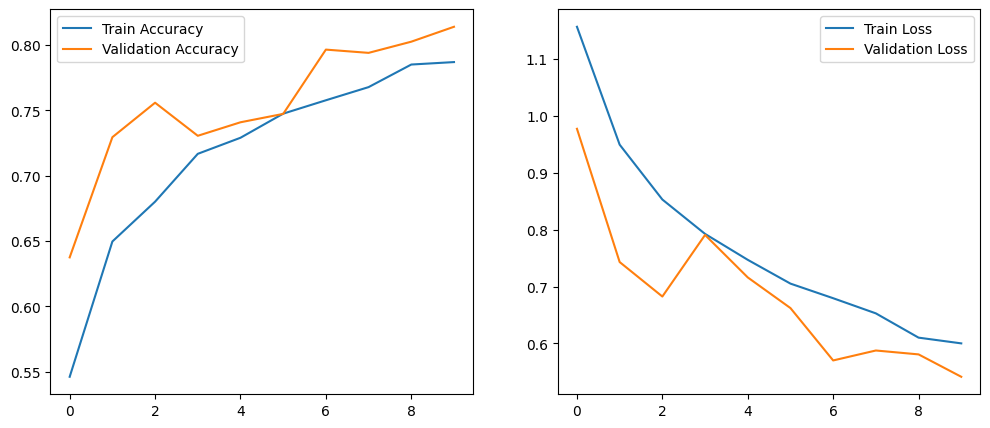

In [71]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()

plt.savefig("cnn_accuracy_loss_curve.png")
plt.savefig("cnn_accuracy_loss_curve.pdf", bbox_inches="tight")
plt.show()

In [72]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

y_pred_probs = cnn_model.predict(test_dataset)

y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions generated successfully")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Predictions generated successfully


# CNN Confusion Matrix

The confusion matrix provides a detailed view of classification performance for each class.

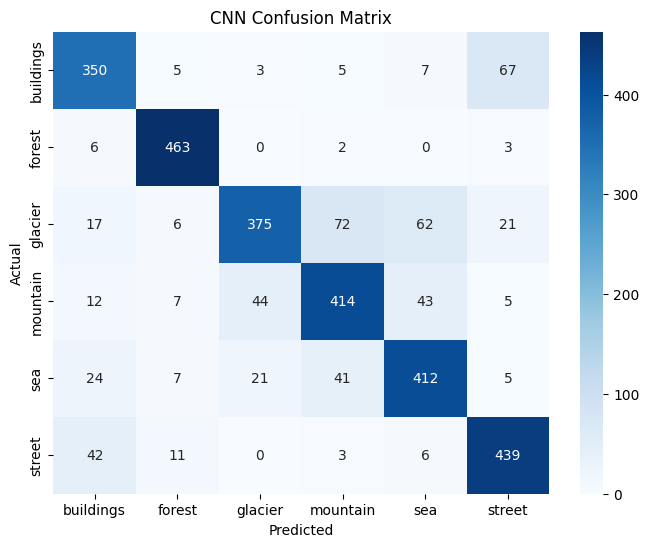

In [73]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("cnn_confusion_matrix.png")
plt.savefig("cnn_confusion_matrix.pdf", bbox_inches="tight")
plt.show()

# CNN Classification Report

Precision, recall, F1-score, and overall accuracy are calculated for the CNN model.

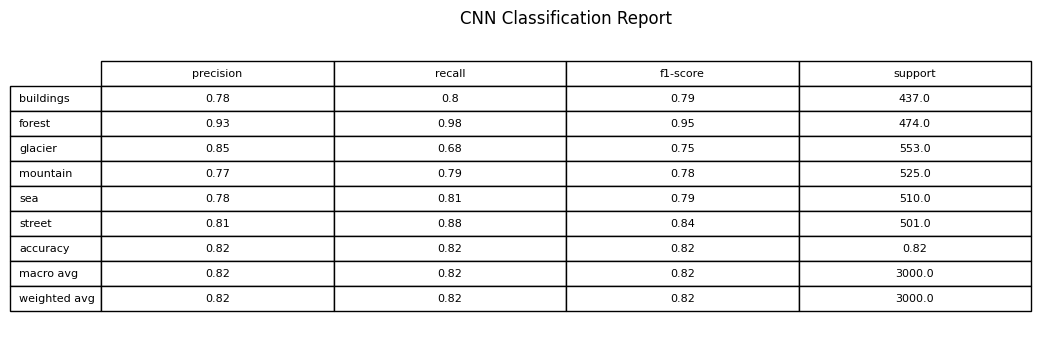

Saved:
classification_report_table.csv
classification_report_table.png


In [74]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Create report dictionary
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Save as CSV
report_df.to_csv("classification_report_table.csv")

# Save as PNG image
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=report_df.round(2).values,
    colLabels=report_df.columns,
    rowLabels=report_df.index,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)

plt.title("CNN Classification Report")
plt.savefig(
    "classification_report_table.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()

print("Saved:")
print("classification_report_table.csv")
print("classification_report_table.png")

# Transfer Learning Model - MobileNetV2

In [75]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

mobilenet_model.summary()

/tmp/ipykernel_58/1910490353.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [76]:
mobilenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 Compiled Successfully")

MobileNetV2 Compiled Successfully


# MobileNetV2 Training and Evaluation

The MobileNetV2 model is trained and evaluated on the same dataset for performance comparison.

In [77]:
mobilenet_history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.7791 - loss: 0.6172 - val_accuracy: 0.8738 - val_loss: 0.3425
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.8304 - loss: 0.4654 - val_accuracy: 0.8596 - val_loss: 0.3591
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8449 - loss: 0.4260 - val_accuracy: 0.8849 - val_loss: 0.3037
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8511 - loss: 0.4035 - val_accuracy: 0.8817 - val_loss: 0.3067
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8563 - loss: 0.3904 - val_accuracy: 0.8792 - val_loss: 0.3196


In [78]:
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(test_dataset)

print("MobileNetV2 Test Accuracy:", mobilenet_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8773 - loss: 0.3213
MobileNetV2 Test Accuracy: 0.8773333430290222


# Model Comparison

The performance of the CNN and MobileNetV2 models is compared using test accuracy.

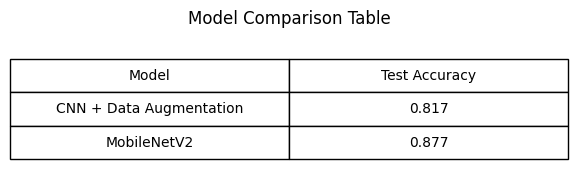

Saved:
model_comparison_table.csv
model_comparison_table.png


<Figure size 640x480 with 0 Axes>

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison table
comparison = pd.DataFrame({
    'Model': ['CNN + Data Augmentation', 'MobileNetV2'],
    'Test Accuracy': [0.817, 0.877]
})

# Save as CSV file
comparison.to_csv("model_comparison_table.csv", index=False)

# Save as image
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')

table = ax.table(
    cellText=comparison.values,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

plt.title("Model Comparison Table")
plt.savefig("model_comparison_table.png",
            bbox_inches='tight',
            dpi=300)

plt.show()

print("Saved:")
print("model_comparison_table.csv")
print("model_comparison_table.png")
plt.savefig("model_comparison.pdf", bbox_inches="tight")

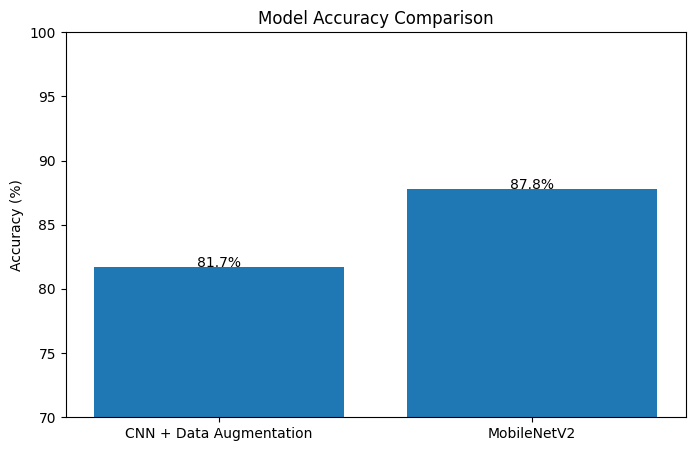

In [91]:
import matplotlib.pyplot as plt

models = ['CNN + Data Augmentation', 'MobileNetV2']
accuracies = [81.7, 87.8]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(70, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center'
    )

plt.savefig('model_comparison.png')
plt.show()

# MobileNetV2 Accuracy and Loss Curves

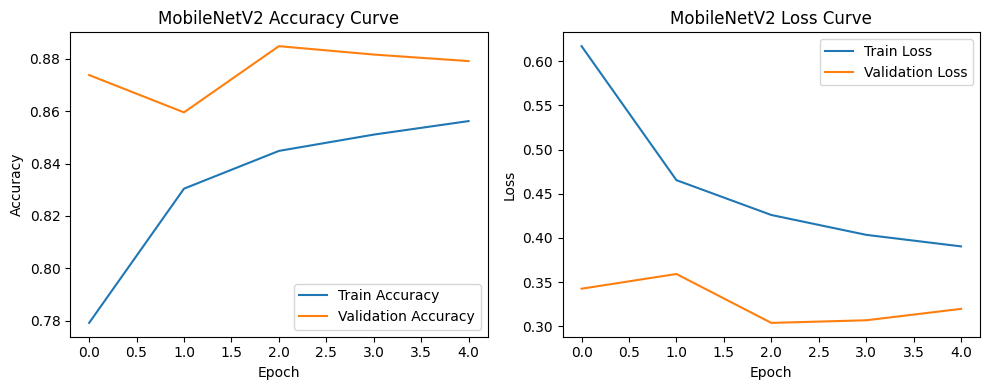

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy Curve
plt.subplot(1,2,1)
plt.plot(mobilenet_history.history['accuracy'], label='Train Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Curve
plt.subplot(1,2,2)
plt.plot(mobilenet_history.history['loss'], label='Train Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("mobilenetv2_accuracy_loss_curve.png")
plt.savefig("mobilenetv2_accuracy_loss_curve.pdf",
            bbox_inches="tight")
plt.show()

# MobileNetV2 ROC Curve Analysis

The Receiver Operating Characteristic (ROC) Curve is used to evaluate the classification performance of the MobileNetV2 transfer learning model across all scene categories.

The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various classification thresholds.

The Area Under the Curve (AUC) indicates the classification capability of the model:

- AUC = 1.0 indicates perfect classification.
- AUC > 0.90 indicates excellent performance.
- AUC > 0.80 indicates good performance.
- AUC = 0.50 indicates random classification.

This analysis helps evaluate how effectively MobileNetV2 distinguishes between different scene classes.

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step


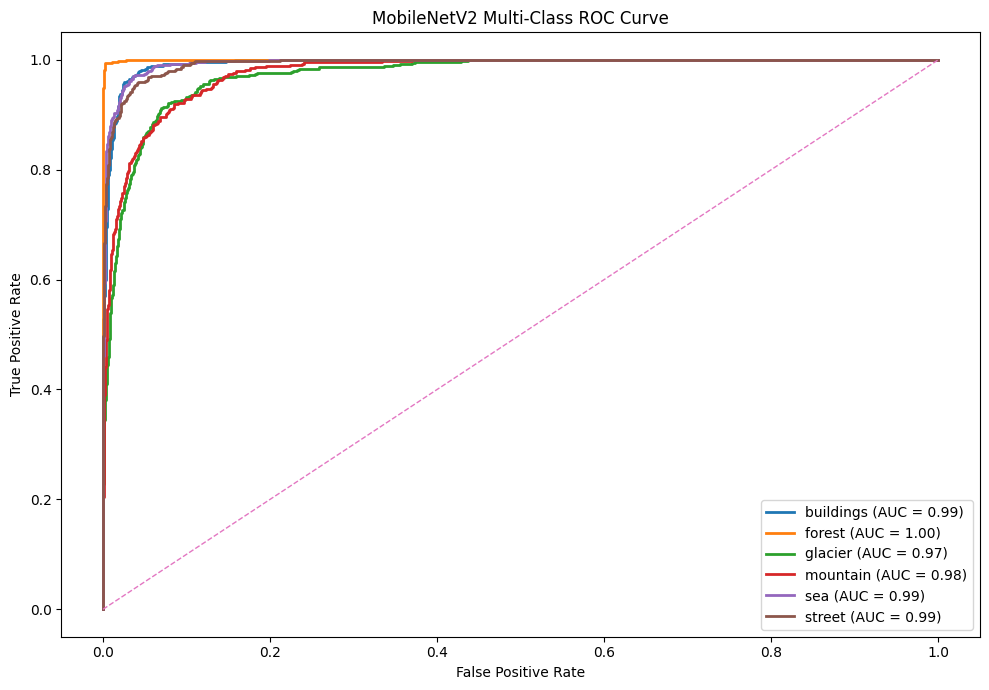

Saved: mobilenetv2_roc_curve.pdf


In [82]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# MobileNetV2 probability predictions
mobilenet_score = mobilenet_model.predict(test_dataset)

# One-hot encode true labels
y_test_bin = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

plt.figure(figsize=(10,7))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        mobilenet_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], '--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNetV2 Multi-Class ROC Curve")
plt.legend(loc="lower right")

plt.tight_layout()

# Save as PDF
plt.savefig(
    "mobilenetv2_roc_curve.pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved: mobilenetv2_roc_curve.pdf")

# MobileNetV2 Confusion Matrix

The confusion matrix provides a detailed analysis of MobileNetV2 classification performance for each scene category.

It summarizes the number of correct and incorrect predictions made by the model and helps identify classes that are frequently confused with one another.

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


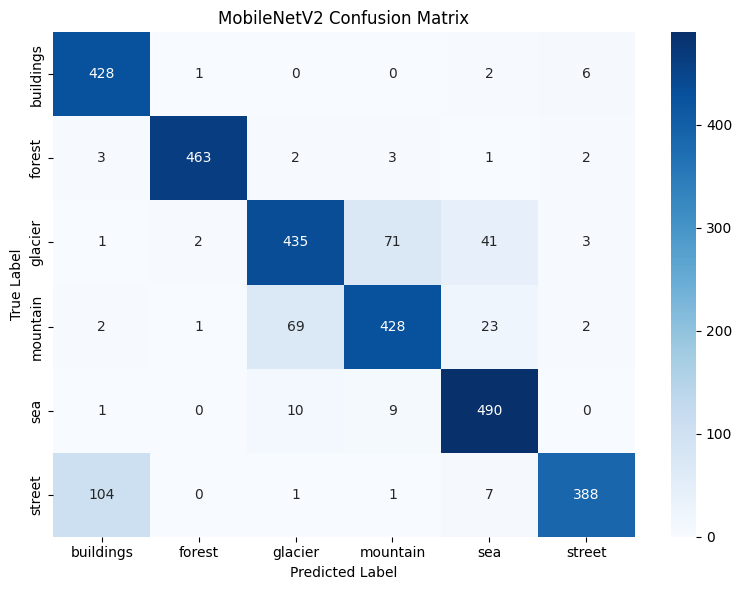

Saved: mobilenetv2_confusion_matrix.pdf


In [83]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# MobileNetV2 Predictions
mobilenet_probs = mobilenet_model.predict(test_dataset)
mobilenet_pred = np.argmax(mobilenet_probs, axis=1)

# Confusion Matrix
cm_mobile = confusion_matrix(y_true, mobilenet_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_mobile,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "mobilenetv2_confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved: mobilenetv2_confusion_matrix.pdf")

# MobileNetV2 Classification Report

The classification report evaluates MobileNetV2 using precision, recall, F1-score, and accuracy metrics for each scene category.

These metrics provide detailed insight into model performance across all classes.

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


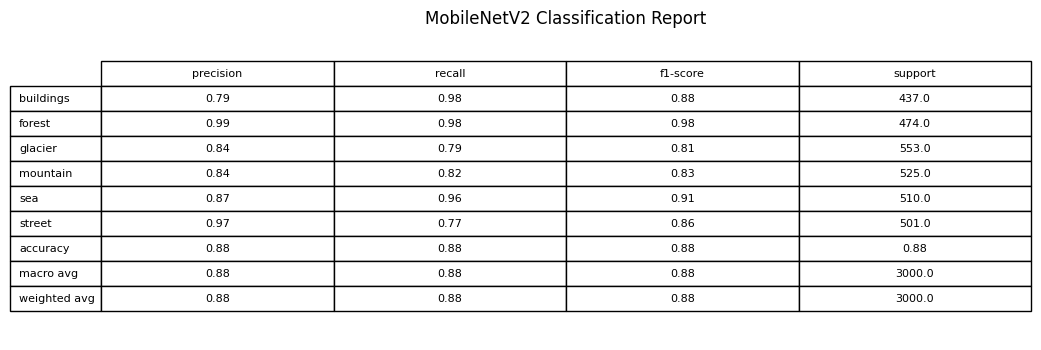

Saved:
mobilenetv2_classification_report.txt
mobilenetv2_classification_report.pdf


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

# MobileNetV2 predictions
mobilenet_probs = mobilenet_model.predict(test_dataset)
mobilenet_pred = np.argmax(mobilenet_probs, axis=1)

# Generate Classification Report
mobilenet_report = classification_report(
    y_true,
    mobilenet_pred,
    target_names=class_names
)



# Save text version
with open(
    "mobilenetv2_classification_report.txt",
    "w"
) as f:
    f.write(mobilenet_report)

# Convert report to DataFrame
report_dict = classification_report(
    y_true,
    mobilenet_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

# Save PDF table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=report_df.round(2).values,
    colLabels=report_df.columns,
    rowLabels=report_df.index,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)

plt.title("MobileNetV2 Classification Report")

plt.savefig(
    "mobilenetv2_classification_report.pdf",
    bbox_inches='tight'
)

plt.show()

print("Saved:")
print("mobilenetv2_classification_report.txt")
print("mobilenetv2_classification_report.pdf")

# Error Analysis

Error analysis was performed to identify the most common misclassification patterns made by the CNN model.

The analysis highlights pairs of classes that are frequently confused and helps understand limitations of the model.

Possible reasons for misclassification include:

- Similar visual characteristics between classes
- Complex backgrounds
- Variations in lighting conditions
- Overlapping scene features

The results can be used to improve model performance through additional training data, data augmentation, or more advanced architectures.

In [85]:

import pandas as pd

errors = pd.DataFrame({
    'Actual': [class_names[i] for i in y_true],
    'Predicted': [class_names[i] for i in y_pred]
})

misclassified = errors[errors['Actual'] != errors['Predicted']]

print("Misclassified Images:", len(misclassified))

Misclassified Images: 547


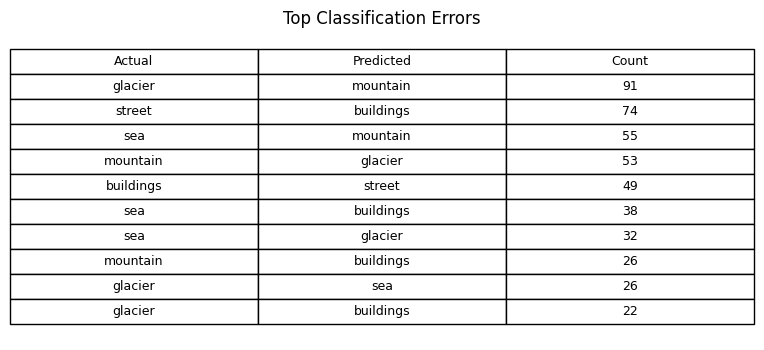

Saved:
error_summary_table.csv
error_summary_table.png


<Figure size 640x480 with 0 Axes>

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# Save Error Summary as CSV
error_summary.to_csv("error_summary_table.csv", index=False)

# Save Error Summary as PNG
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

table = ax.table(
    cellText=error_summary.head(10).values,
    colLabels=error_summary.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

plt.title("Top Classification Errors")
plt.savefig(
    "error_summary_table.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()
plt.savefig("error_analysis.pdf", bbox_inches="tight")

print("Saved:")
print("error_summary_table.csv")
print("error_summary_table.png")

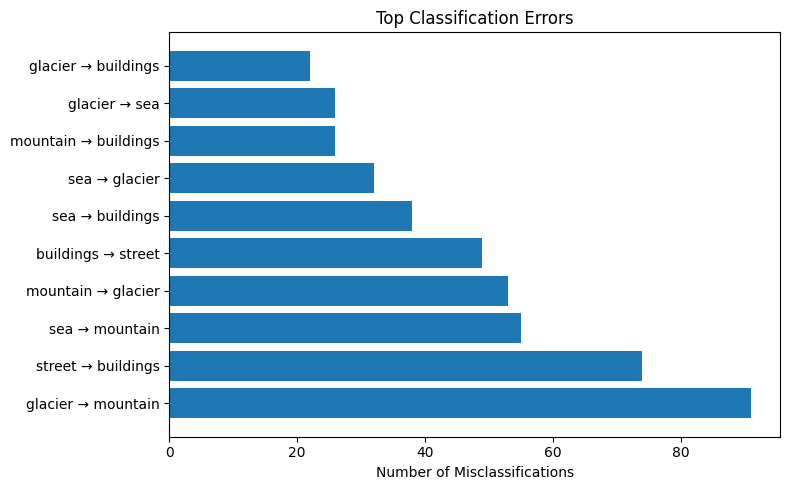

In [87]:
import matplotlib.pyplot as plt

top_errors = error_summary.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_errors['Actual'] + " → " + top_errors['Predicted'],
    top_errors['Count']
)

plt.xlabel("Number of Misclassifications")
plt.title("Top Classification Errors")

plt.tight_layout()
plt.savefig("error_analysis.png")
plt.savefig("error_analysis.pdf")
plt.show()

# Conclusion

The custom CNN achieved 81.7% test accuracy, while MobileNetV2 achieved 87.8% test accuracy. Transfer learning significantly improved classification performance, making MobileNetV2 the best-performing model for this project.